In [1]:
# Install required packages
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q accelerate bitsandbytes pillow datasets peft

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.0/502.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.1/47.1 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.1.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 5.0.0.dev0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 12.2 MB/s eta 0:00:00


In [2]:
# Import libraries
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration
from transformers import TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import requests
from io import BytesIO
import zipfile
from pathlib import Path
from datasets import load_dataset

In [3]:
# Clone the PlantDoc dataset
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git

# Set up paths
dataset_path = "PlantDoc-Dataset"
train_path = os.path.join(dataset_path, "train")
test_path = os.path.join(dataset_path, "test")


Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 2670 (delta 22), reused 22 (delta 22), pack-reused 2635 (from 1)
Receiving objects: 100% (2670/2670), 932.92 MiB | 31.64 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.


In [4]:
# Create image-caption pairs from the dataset
def create_dataset_dict():
    data = {"image": [], "text": []}

    # Process train folder
    if os.path.exists(train_path):
        for class_folder in os.listdir(train_path):
            class_path = os.path.join(train_path, class_folder)
            if os.path.isdir(class_path):
                for img_file in os.listdir(class_path):
                    if img_file.endswith(('.jpg', '.jpeg', '.png')):
                        img_path = os.path.join(class_path, img_file)
                        # Create caption from class name
                        caption = f"This is a plant leaf with {class_folder.replace('_', ' ')}"
                        data["image"].append(img_path)
                        data["text"].append(caption)

    return data

In [5]:
# Load dataset
dataset_dict = create_dataset_dict()
print(f"Total images: {len(dataset_dict['image'])}")

Total images: 2342


In [6]:
# Custom Dataset class
class PlantDiseaseDataset(Dataset):
    def __init__(self, image_paths, captions, processor):
        self.image_paths = image_paths
        self.captions = captions
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        caption = self.captions[idx]

        # Process image and text
        encoding = self.processor(images=image, text=caption,
                                 padding="max_length", max_length=32,
                                 truncation=True, return_tensors="pt")

        # Remove batch dimension
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        encoding["labels"] = encoding["input_ids"].clone()

        return encoding

In [7]:
# Load BLIP-2 model with 8-bit quantization (to save memory)
from transformers import BitsAndBytesConfig

processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

# Configure 8-bit quantization
quantization_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.float16
)

# Load model with quantization config
model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.float16
)

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/10.0G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [8]:
# Prepare model for LoRA fine-tuning
model = prepare_model_for_kbit_training(model)

In [9]:
# Configure LoRA
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    target_modules=["q_proj", "v_proj"]
)

In [10]:
# Apply LoRA to model
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 2,621,440 || all params: 3,747,383,296 || trainable%: 0.0700


In [20]:
# Use FULL dataset for better results
train_dataset = PlantDiseaseDataset(
    dataset_dict['image'],
    dataset_dict['text'],
    processor
)

print(f"Training on {len(train_dataset)} samples")

Training on 2342 samples


In [21]:
# Training arguments optimized for T4 GPU
training_args = TrainingArguments(
    output_dir="./blip2-plantdoc-lora",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=5e-5,
    warmup_steps=50,
    logging_steps=10,
    save_steps=100,
    save_total_limit=2,
    fp16=True,
    dataloader_num_workers=2,
    remove_unused_columns=False,
    report_to="none"
)

In [22]:
# Custom Trainer
class BLIP2Trainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        outputs = model(**inputs)
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

In [23]:
# Custom Trainer
class BLIP2Trainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        outputs = model(**inputs)
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

# Initialize trainer
trainer = BLIP2Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
)

# Start training
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:181: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss
10,2.615300
20,2.635500
30,2.296200
40,1.899700
50,1.823700
60,1.483900
70,1.296000
80,1.147400
90,1.055800
100,0.961300


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:181: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarni

TrainOutput(global_step=879, training_loss=0.6056426417705549, metrics={'train_runtime': 5616.2973, 'train_samples_per_second': 1.251, 'train_steps_per_second': 0.157, 'total_flos': 2.2929129438978245e+19, 'train_loss': 0.6056426417705549, 'epoch': 3.0})

In [24]:
# Save the fine-tuned LoRA adapters
model.save_pretrained("./blip2-plantdoc-lora-final")
processor.save_pretrained("./blip2-plantdoc-lora-final")

['./blip2-plantdoc-lora-final/processor_config.json']

In [25]:
# Test inference
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to("cuda", torch.float16)

    generated_ids = model.generate(**inputs, max_new_tokens=50)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

    return generated_text

In [26]:
# Test on a sample image
test_image = dataset_dict['image'][0]
caption = generate_caption(test_image)
print(f"Generated caption: {caption}")

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:181: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Generated caption: This


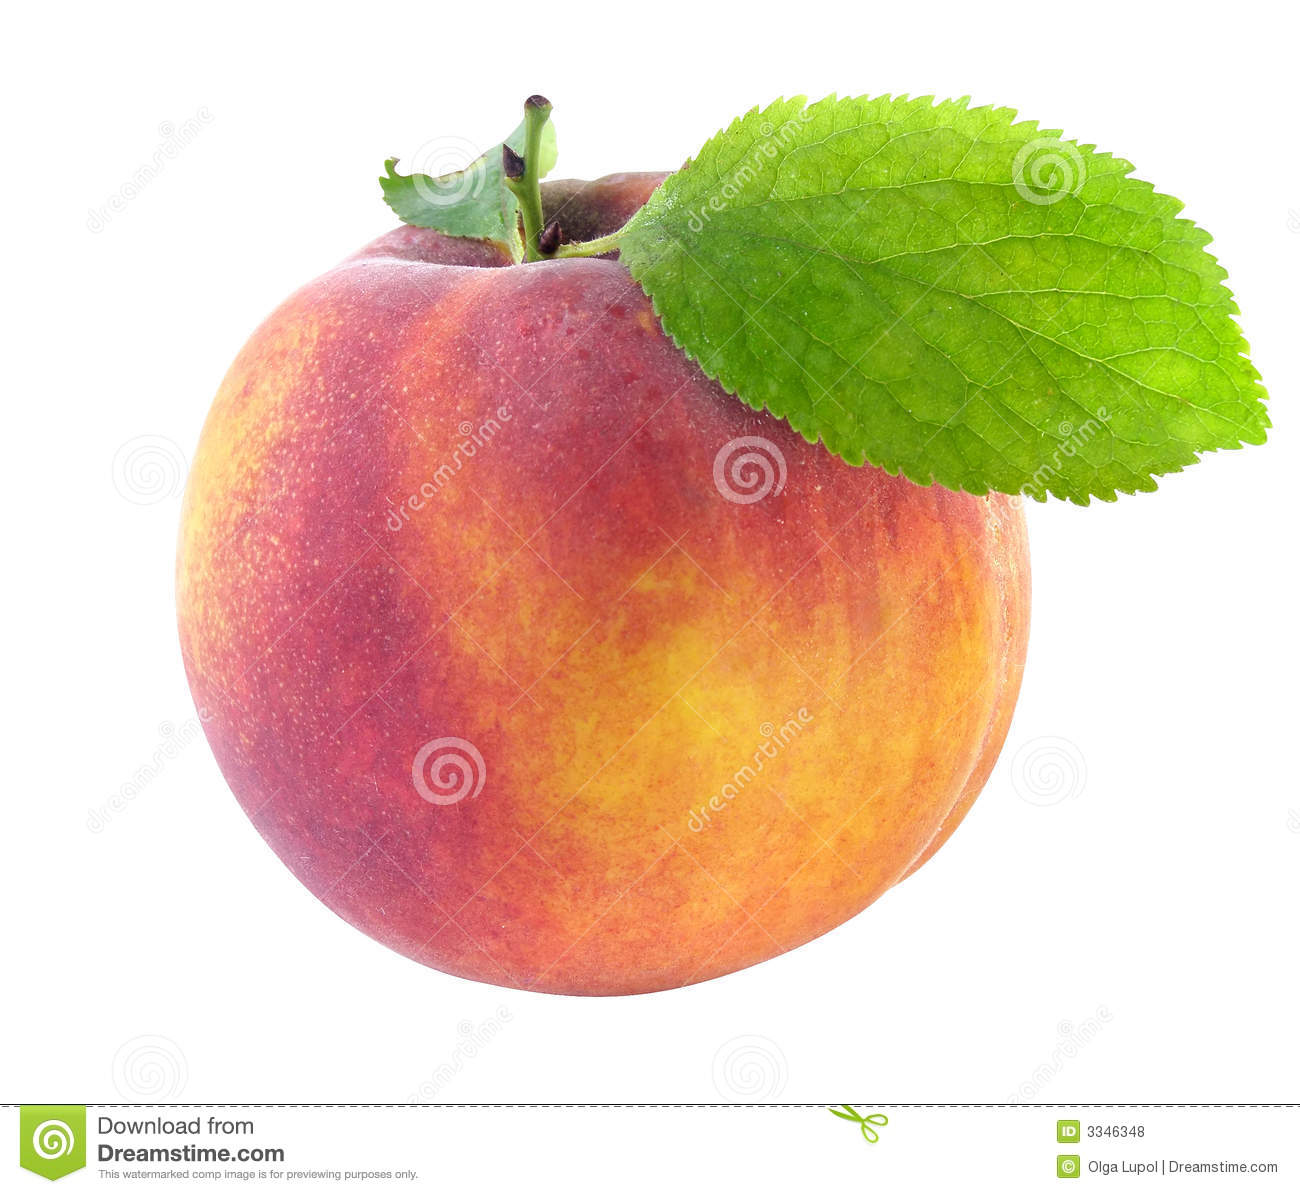

In [27]:
# Display test image
from IPython.display import display
display(Image.open(test_image))

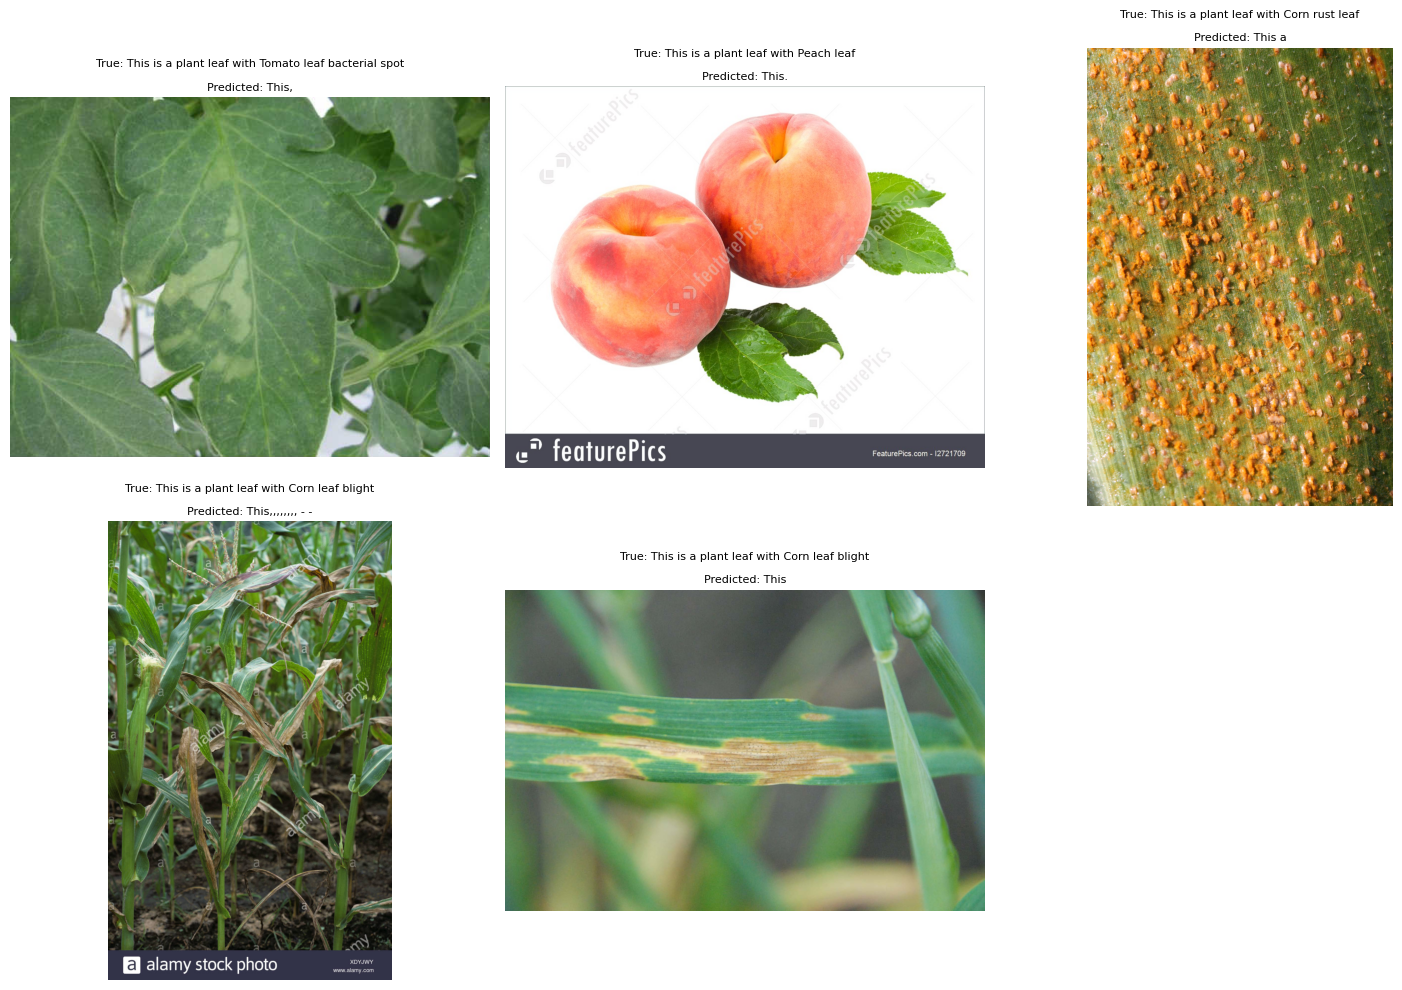

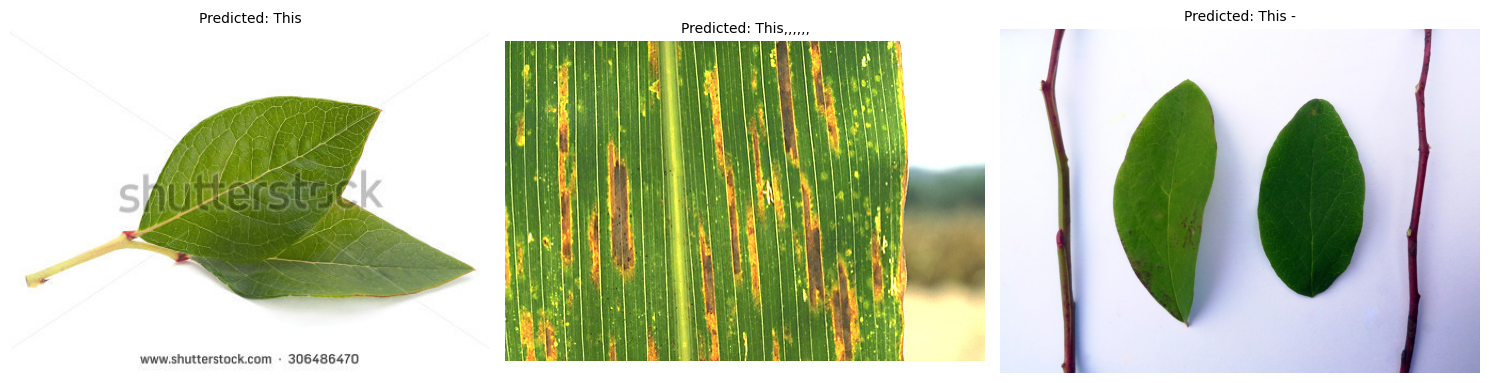


Testing complete!


In [19]:
# Test the fine-tuned model on multiple samples
import matplotlib.pyplot as plt
from PIL import Image

# Function to generate caption for an image
def generate_caption(image_path, model, processor):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to("cuda", torch.float16)

    generated_ids = model.generate(**inputs, max_new_tokens=50)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

    return generated_text

# Test on 5 random samples from dataset
import random
test_indices = random.sample(range(len(dataset_dict['image'])), min(5, len(dataset_dict['image'])))

plt.figure(figsize=(15, 10))

for idx, test_idx in enumerate(test_indices):
    test_image_path = dataset_dict['image'][test_idx]
    true_caption = dataset_dict['text'][test_idx]

    # Generate caption
    predicted_caption = generate_caption(test_image_path, model, processor)

    # Display image and captions
    plt.subplot(2, 3, idx + 1)
    img = Image.open(test_image_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_caption}\n\nPredicted: {predicted_caption}",
              fontsize=8, wrap=True)

plt.tight_layout()
plt.show()

# Test on test set images if available
if os.path.exists(test_path):
    test_images = []
    for class_folder in os.listdir(test_path):
        class_path = os.path.join(test_path, class_folder)
        if os.path.isdir(class_path):
            for img_file in os.listdir(class_path):
                if img_file.endswith(('.jpg', '.jpeg', '.png')):
                    test_images.append(os.path.join(class_path, img_file))

    # Test on 3 random test images
    if test_images:
        test_samples = random.sample(test_images, min(3, len(test_images)))

        plt.figure(figsize=(15, 5))

        for idx, img_path in enumerate(test_samples):
            predicted_caption = generate_caption(img_path, model, processor)

            plt.subplot(1, 3, idx + 1)
            img = Image.open(img_path)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Predicted: {predicted_caption}", fontsize=10)

        plt.tight_layout()
        plt.show()

print("\nTesting complete!")

In [28]:
# Test fine-tuned model on same 15 images
import matplotlib.pyplot as plt
from PIL import Image
import random

# Set up test dataset paths
dataset_path = "PlantDoc-Dataset"
test_path = os.path.join(dataset_path, "test")

# Create test dataset with ground truth labels
def create_test_dataset():
    data = {"image": [], "label": [], "class_name": []}

    if os.path.exists(test_path):
        for class_folder in os.listdir(test_path):
            class_path = os.path.join(test_path, class_folder)
            if os.path.isdir(class_path):
                for img_file in os.listdir(class_path):
                    if img_file.endswith(('.jpg', '.jpeg', '.png')):
                        img_path = os.path.join(class_path, img_file)
                        data["image"].append(img_path)
                        data["label"].append(class_folder)
                        data["class_name"].append(class_folder.replace('_', ' '))

    return data

In [29]:
# Load test dataset
test_data = create_test_dataset()
print(f"Total test images: {len(test_data['image'])}")

# Function to generate caption with fine-tuned model
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to("cuda", torch.float16)

    generated_ids = model.generate(**inputs, max_new_tokens=50)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

    return generated_text

Total test images: 236


In [30]:
# Select 15 random test samples
random.seed(42)  # Set seed for reproducibility
test_indices = random.sample(range(len(test_data['image'])), min(15, len(test_data['image'])))

# Store results for evaluation
results = {
    "image_path": [],
    "true_label": [],
    "predicted_caption": [],
    "match": []
}

In [31]:
# Test on 15 images with fine-tuned model
print("\n" + "="*60)
print("TESTING FINE-TUNED MODEL")
print("="*60)

for idx in test_indices:
    img_path = test_data['image'][idx]
    true_label = test_data['class_name'][idx]

    # Generate caption with fine-tuned model
    predicted_caption = generate_caption(img_path)

    # Check if true label keywords are in predicted caption
    keywords = true_label.lower().split()
    match = any(keyword in predicted_caption.lower() for keyword in keywords)

    results["image_path"].append(img_path)
    results["true_label"].append(true_label)
    results["predicted_caption"].append(predicted_caption)
    results["match"].append(match)

    print(f"\n{len(results['image_path'])}/15 - True: {true_label}")
    print(f"Predicted: {predicted_caption}")
    print(f"Match: {'✓' if match else '✗'}")

# Calculate metrics
total_samples = len(results["match"])
correct_predictions = sum(results["match"])
accuracy = (correct_predictions / total_samples) * 100

print("\n" + "="*60)
print("FINE-TUNED MODEL EVALUATION METRICS")
print("="*60)
print(f"Total Test Samples: {total_samples}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {total_samples - correct_predictions}")
print(f"Accuracy: {accuracy:.2f}%")
print("="*60)


TESTING FINE-TUNED MODEL

1/15 - True: Tomato mold leaf
Predicted: This,,,,,,,,,,,,," "
Match: ✗

2/15 - True: Blueberry leaf
Predicted: This..............................................
Match: ✗

3/15 - True: Peach leaf
Predicted: This,,,,,,,,,,,,,,,,
Match: ✗

4/15 - True: Potato leaf early blight
Predicted: This..........,,,,,,,,,,,,,,,,,..................'
Match: ✗

5/15 - True: Tomato leaf
Predicted: This,,,,,,,,,,,,,
Match: ✗

6/15 - True: grape leaf
Predicted: This
Match: ✗

7/15 - True: grape leaf
Predicted: This
Match: ✗

8/15 - True: Blueberry leaf
Predicted: This" - - "
Match: ✗

9/15 - True: Corn Gray leaf spot
Predicted: This...
Match: ✗

10/15 - True: Blueberry leaf
Predicted: This",,,,,,,,,,,] [ -..............
Match: ✗

11/15 - True: Soyabean leaf
Predicted: This,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Match: ✗

12/15 - True: Apple Scab Leaf
Predicted: This....,,,,,,,,,,,,,,,,,,,,,
Match: ✗

13/15 - True: Bell pepper leaf
Predicted: This..................."",

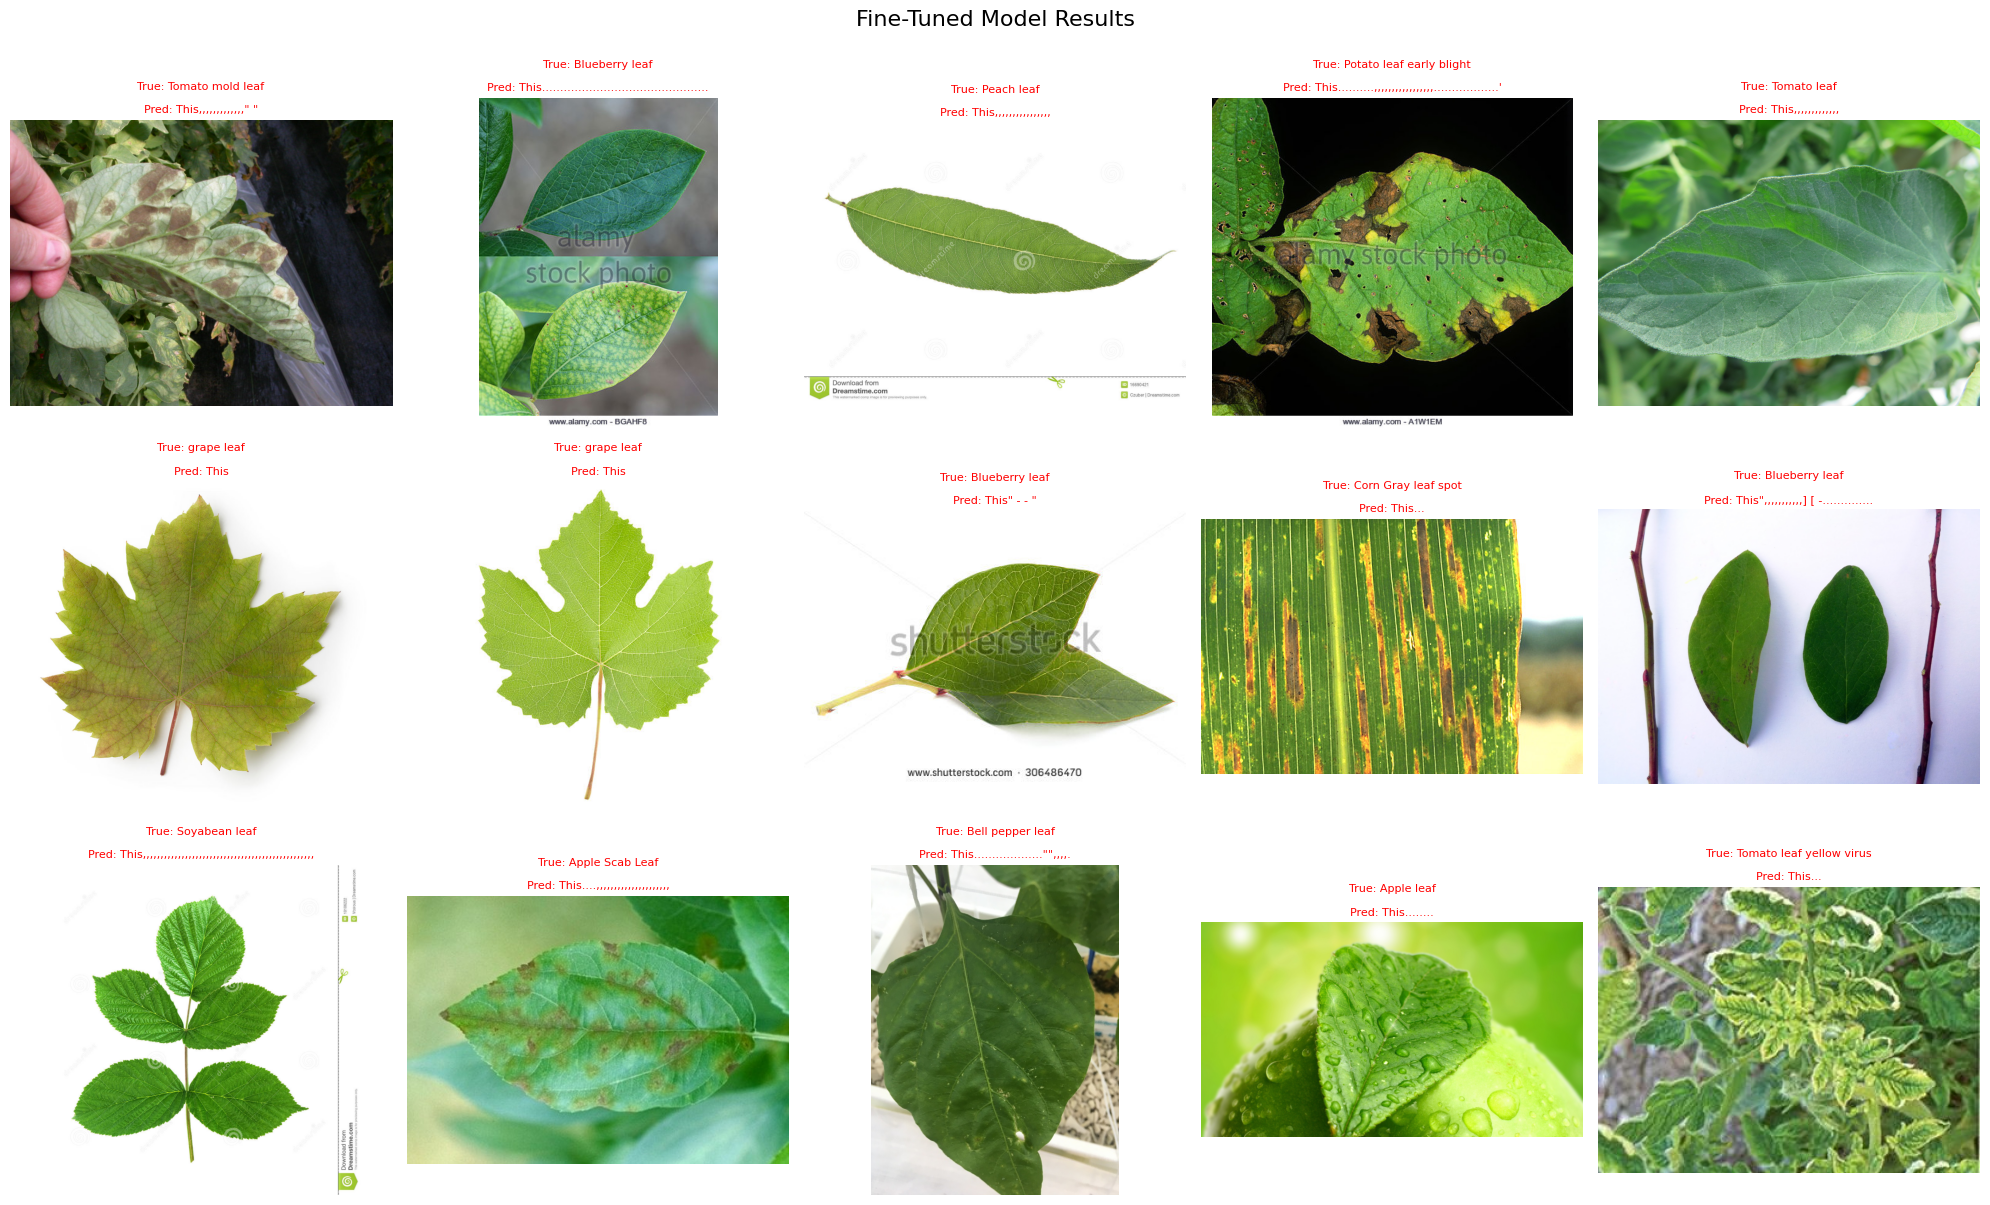

In [32]:
# Visualize results
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for idx in range(15):
    img = Image.open(results["image_path"][idx])
    axes[idx].imshow(img)
    axes[idx].axis('off')

    # Color code: green for match, red for no match
    color = 'green' if results["match"][idx] else 'red'
    title = f"True: {results['true_label'][idx]}\n\nPred: {results['predicted_caption'][idx]}"
    axes[idx].set_title(title, fontsize=8, color=color, wrap=True)

plt.suptitle('Fine-Tuned Model Results', fontsize=16, y=1.00)
plt.tight_layout()
plt.savefig('finetuned_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Detailed results table
print("\nDETAILED RESULTS (FINE-TUNED MODEL):")
print("-" * 100)
print(f"{'#':<3} {'True Label':<30} {'Predicted Caption':<50} {'Match':<5}")
print("-" * 100)

for i in range(len(results["image_path"])):
    match_symbol = '✓' if results["match"][i] else '✗'
    print(f"{i+1:<3} {results['true_label'][i]:<30} {results['predicted_caption'][i]:<50} {match_symbol:<5}")

print("-" * 100)


DETAILED RESULTS (FINE-TUNED MODEL):
----------------------------------------------------------------------------------------------------
#   True Label                     Predicted Caption                                  Match
----------------------------------------------------------------------------------------------------
1   Tomato mold leaf               This,,,,,,,,,,,,," "                               ✗    
2   Blueberry leaf                 This.............................................. ✗    
3   Peach leaf                     This,,,,,,,,,,,,,,,,                               ✗    
4   Potato leaf early blight       This..........,,,,,,,,,,,,,,,,,..................' ✗    
5   Tomato leaf                    This,,,,,,,,,,,,,                                  ✗    
6   grape leaf                     This                                               ✗    
7   grape leaf                     This                                               ✗    
8   Blueberry leaf      